# From a relaxed packing to an exact side length

A relaxed packing is a *numerical* object. Its side length is good to eight or nine digits, because the
contact law is soft and the last step is a bisection on overlap area. No amount of extra minimization
fixes that -- the force noise floor is around `3e-12`.

The contact graph is a **combinatorial** object. "Does square 7's corner touch square 3's face" is a
yes/no question, and nine digits answers it comfortably. That asymmetry is the whole method:

> **optimization supplies the combinatorics, and root-finding supplies the digits.**

Once the contacts are known they are a system of polynomial equations. Newton on that system converges
quadratically, so the precision is whatever `mpmath` is asked for, and the side length comes out as an
algebraic number you can name.

### The formalization

Square `i` carries `(x, y, a, b)` with `a = cos(theta)`, `b = sin(theta)` and `a^2 + b^2 = 1` as an
explicit equation -- angles are avoided so that everything stays **polynomial**. Add the box side `s`
and there are `3N + 1` real degrees of freedom.

There is only one kind of contact equation:

    a vertex of i on an edge of j:   n_j^m . (v_i^k - c_j) = 1/2
    a vertex of i on a wall:         v_i^k.x = 0,  = s,  and likewise in y

A flush face-to-face contact is **not** a separate case -- it shows up as two vertex-on-edge equations,
which together force both the parallelism and the separation. That is why no edge-edge primitive
appears anywhere in `contacts.py`.

In [1]:
import os
import sys

# The modules live at the repo root, but a Jupyter kernel starts in the notebook's OWN directory, so
# walk up until model.py is in sight. Works whether this is opened from tests/ or from the root.
root = os.getcwd()
while not os.path.isfile(os.path.join(root, "model.py")) and root != os.path.dirname(root):
    root = os.path.dirname(root)
if root not in sys.path:
    sys.path.insert(0, root)
if os.path.join(root, "tests") not in sys.path:
    sys.path.insert(0, os.path.join(root, "tests"))

import numpy as np
import mpmath as mp
from matplotlib import pyplot as plt

import contacts as ct
import records
import refine as rf
import squeeze as sq
from makePackings import load

## 1. Pick a packing

`data/packingKnown5.npz` is the **self-test**: the proved n = 5 optimum, `s = 2 + sqrt(2)/2`, jittered
by `1e-9` so it looks exactly like something the minimizer produced. If the pipeline recovers that
expression from it, the machinery is sound.

`data/packing11.npz` is a real relaxed packing -- a valid one, but nowhere near the record. That is
the interesting case: it has a genuine contact graph of its own, and refining it says exactly what
*that* structure is worth.

In [2]:
source = "/home/rdennis/Documents/Code/pyPolygon/tests/test26"          # or "packing11.npz", or your own saved packing
digits = 90                           # mpmath working precision; 300 for a serious identification

packing = load(source, containerIndex = 26)
state, startingSide = ct.unitState(packing)
count = (len(state) - 1) // 4
print(f"{count} squares, side {startingSide:.12f}")
print(records.describe(count, startingSide))

26 squares, side 5.596901035825
n = 26: best known (not proved) is side 5.62132034 = 7/2 + 3 sqrt(2)/2;  this run reached 5.596901, -0.434%


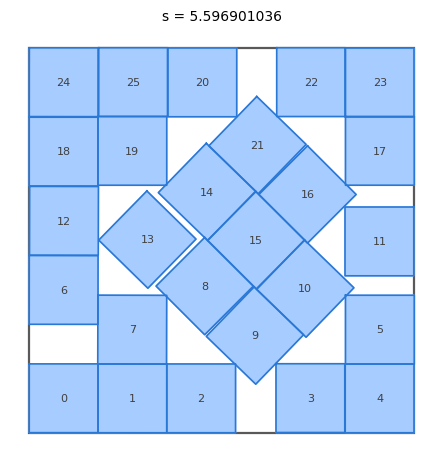

In [3]:
def draw(state, count, rattlers = (), flexible = (), axis = None, labels = True):
    """The unit-square packing in its box. The box side IS the answer, so it is drawn to scale.

    RED IS A RATTLER -- the contacts do not hold it, so it carries three unknowns and too few equations
    and must come OUT before the system is solved. AMBER is first-order flexible but second-order
    rigid: pinned in position, but with one direction the contacts do not constrain at first order.
    Those are NOT rattlers and deleting them wrecks the packing -- in the proved n = 5 optimum the
    amber square is the tilted one in the middle that everything else bears on."""
    if axis is None:
        _, axis = plt.subplots(figsize = (5.5, 5.5))
    s = state[-1]
    axis.add_patch(plt.Rectangle((0, 0), s, s, fill = False, lw = 1.6, color = "0.35"))
    for i in range(count):
        x, y, a, b = state[4 * i:4 * i + 4]
        corner = 0.5 * np.array([[1, 1], [-1, 1], [-1, -1], [1, -1]], dtype = float)
        loop = corner @ np.array([[a, b], [-b, a]]) + np.array([x, y])
        if i in rattlers:
            fill, edge = "#f2b0b0", "#c0392b"
        elif i in flexible:
            fill, edge = "#ffe0a3", "#d68910"
        else:
            fill, edge = "#9ec7ff", "#2a78d6"
        axis.fill(*np.vstack([loop, loop[:1]]).T, color = fill, alpha = 0.9)
        axis.plot(*np.vstack([loop, loop[:1]]).T, color = edge, lw = 1.2)
        if labels:
            axis.text(x, y, str(i), ha = "center", va = "center", fontsize = 8, color = "0.25")
    axis.set_xlim(-0.05 * s, 1.05 * s); axis.set_ylim(-0.05 * s, 1.05 * s)
    axis.set_aspect("equal"); axis.axis("off")
    return axis

draw(state, count).set_title(f"s = {state[-1]:.9f}", fontsize = 10)
plt.show()

## 1b. Close the packing

**A relaxed packing is decompressed, and that is not the same as wrong.** A protocol that ends by
bisecting down to zero overlap stops at the largest size that is valid with the arrangement *frozen*,
and the depth law has zero energy *and zero force* there, so nothing rearranges. The slack it leaves is
distributed unevenly -- measured on `close26Test.npz`, eleven wall gaps between `1.00e-03` and
`1.15e-03`, pair gaps at roughly twice that -- so no single rescale closes them and every gap reads as
a near-miss rather than a contact.

`squeeze` holds the squares unit and **minimizes the box side** over all centers, angles and `s` at
once, subject to non-overlap. That is not convex -- non-overlap is a disjunction, *some* separating
axis must work -- but fixing one axis per pair is a convex restriction that is tight at contact, and a
linear one once the rotations are linearized. So each iteration is a linear program in `3N + 1`
variables inside a trust region: Torquato and Jiao's adaptive shrinking cell, specialized to squares.

The contact graph is then the **active set** at convergence, so no tolerance has to be guessed. On the
26-square packing this closes the gaps from `1e-03` to `2e-14` and takes the side from `5.633361` to
`5.621320343560` -- the best known value, `7/2 + 3 sqrt(2)/2`. The entire 0.214% shortfall was slack.

It also **repairs an invalid start**, which matters more than it sounds: an overlapping packing reports
a side that *beats* the record, because it is not a packing.


  invalid on entry: worst violation 1.446e-02 -- relieving
  relieved in 19 steps: s = 5.738307285825, valid
  step     0  radius 2.00e-02  s = 5.718307285825
  stopped after 80 steps: s = 5.621320343560
5.596901035825  ->  5.621320343560
n = 26: best known (not proved) is side 5.62132034 = 7/2 + 3 sqrt(2)/2;  this run reached 5.621320, +0.000%


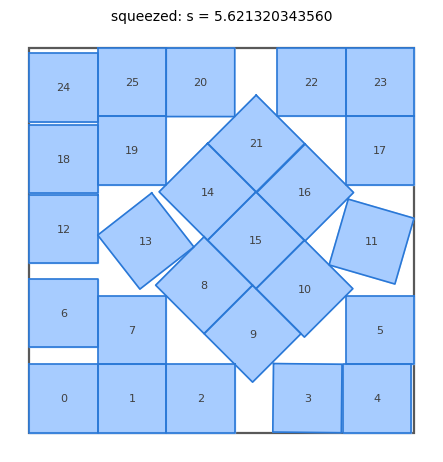

In [4]:
packing, squeezedSide = sq.closePacking(packing)
state, _ = ct.unitState(packing)
print(f"{startingSide:.12f}  ->  {squeezedSide:.12f}")
print(records.describe(count, squeezedSide))

draw(state, count).set_title(f"squeezed: s = {state[-1]:.12f}", fontsize = 10)
plt.show()


## 2. Choose the tolerance by looking, not by guessing

**This is the step that decides everything, and "everything is a rattler" is what it looks like when it
is wrong.** A relaxed packing's contacts do not sit at zero: a protocol that ends on a bisection stops
at the largest *valid* size, and the final relaxation then disengages every contact by whatever slack
the bisection left. Too tight and every square is a rattler; too loose and spurious pairs
over-constrain the system, which surfaces later as a Newton residual that never falls, or as a
converged answer that violates a non-overlap inequality.

The tolerance is in **square-side units** -- the state has already been rescaled to unit squares, so
`1e-6` means a millionth of a square's side, not of the box.

Read the ladder. **A real contact set is stable across decades.** If the count sits on a plateau with no
rattlers, that plateau is the answer and its middle is the tolerance to use. If the count climbs
steadily instead, there is no separation between a contact and a near-miss, which means the packing is
not jammed -- and no buffer fixes that.

In [5]:
spectrum = ct.gaps(state, count)
print("smallest gaps (square-side units):")
print("   ", np.array2string(spectrum[:10], precision = 3))
print()
print(f"{'tolerance':>10} {'contacts':>9} {'rattlers':>9} {'equations':>10} {'unknowns':>9}  verdict")
for level, found, loose, equations, unknowns, verdict in ct.toleranceLadder(state, count):
    print(f"{level:10.0e} {found:9d} {loose:9d} {equations:10d} {unknowns:9d}  {verdict}")

suggested = ct.suggestTolerance(state, count)
print()
if suggested is None:
    print("NO PLATEAU. The gaps grade smoothly, so nothing separates a contact from a near-miss.")
    print("This packing is not jammed -- see the note below.")
else:
    print(f"suggested tolerance {suggested:.2e}  (middle of the widest rattler-free plateau)")

smallest gaps (square-side units):
    [1.110e-16 4.441e-16 8.882e-16 8.882e-16 9.992e-16 1.221e-15 1.554e-15
 2.685e-15 3.331e-15 3.331e-15]

 tolerance  contacts  rattlers  equations  unknowns  verdict
     1e-10       100         5         94        64  hyperstatic
     1e-09       100         5         94        64  hyperstatic
     1e-08       100         5         94        64  hyperstatic
     1e-07       100         5         94        64  hyperstatic
     1e-06       101         5         94        64  hyperstatic
     1e-05       107         4        102        67  hyperstatic
     1e-04       107         4        102        67  hyperstatic
     1e-03       109         4        103        67  hyperstatic
     1e-02       120         4        113        67  hyperstatic

suggested tolerance 1.00e-09  (middle of the widest rattler-free plateau)


**If there is still no plateau after the squeeze**, the gaps genuinely grade smoothly and there is no
contact graph to read. Before the squeeze this was the normal outcome, and the cure was to save the
state at the **jamming point** instead -- hold a small excess energy (`holdExcessEnergy`, or the
`holdExcess` in `cornerCutSquares`) and read that rather than the decompressed state. Measured on such
a run: one gap at `2.6e-08` and the next at `2.4e-04`, eleven rattlers, and a contact count that
climbed `0, 0, 0, 1, 1, 1, 1, 2, 14` straight through the ladder.

**Rattlers on the plateau are normal and are not a symptom.** The squeezed 26-square packing has five
of them and sits exactly on the record. Only *every* square being loose means unjammed.


## 2. Audit the contact graph

The verdict is the thing to read, and the three cases mean different things:

| | |
|---|---|
| **isostatic** | equations `== 3N + 1`. The system pins every coordinate and `s`. |
| **hypostatic** | fewer. Something can still move, so this is **not** a local maximum and `s` is not determined -- almost always a rattler that has not been removed. |
| **hyperstatic** | more. Normal at real optima, where symmetry makes contacts dependent. Overdetermined but consistent; the test is whether the residual actually reaches zero. |

**Rattlers must come out before anything is solved.** A loose square adds three unknowns and too few
equations, so leaving one in makes the whole system underdetermined and no amount of Newton converges.
They are found by peeling: anything with fewer than three contacts is loose, and removing it can drop
a neighbour below three in turn.

In [6]:
tolerance = suggested          # or set it by hand from the ladder above
audit = ct.audit(state, count, tolerance = tolerance)
print(f"contacts   {len(audit['contacts'])} found, {len(audit['equations'])} as equations")
print(f"           {len(audit['corners'])} vertex-vertex touches, which are NOT equations")
print(f"rattlers   {list(audit['rattlers'])}")
print(f"system     {len(audit['equations'])} equations against {audit['unknowns']} unknowns"
      f"  ->  {audit['verdict'].upper()}")
print()
print("per-square contact count:", ct.contactCounts(audit["equations"], count))

contacts   100 found, 94 as equations
           0 vertex-vertex touches, which are NOT equations
rattlers   [3, 11, 12, 13, 20]
system     94 equations against 64 unknowns  ->  HYPERSTATIC

per-square contact count: [ 6 12  9  0  4  5  4 11  5  5  9  0  0  0  9 16  5  9  4  9  0  5  9 12
  6  8]


rattlers  [3, 11, 12, 13, 20]
flexible  [0, 4, 6, 8, 9, 16, 18, 21, 24]   (rank [3, 3, 3, 3, 3, 3, 3, 3, 3] of 4 -- NOT rattlers, do not remove)
pinned    [1, 2, 5, 7, 10, 14, 15, 17, 19, 22, 23, 25]


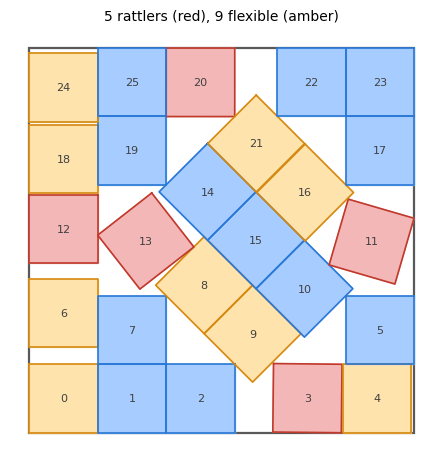

In [7]:
# RED = rattler, AMBER = first-order flexible but second-order rigid, BLUE = fully pinned.
ranks = ct.localRanks(state, audit["equations"], count)
flexible = [i for i in audit["free"] if ranks[i] < 4]
print(f"rattlers  {list(audit['rattlers'])}")
print(f"flexible  {flexible}   (rank {list(ranks[flexible])} of 4 -- NOT rattlers, do not remove)")
print(f"pinned    {[i for i in audit['free'] if i not in flexible]}")

axis = draw(state, count, rattlers = set(audit["rattlers"]), flexible = set(flexible))
axis.set_title(f"{len(audit['rattlers'])} rattlers (red), {len(flexible)} flexible (amber)",
               fontsize = 10)
plt.show()

A **vertex-vertex** touch is reported separately and deliberately excluded. Two corners meeting is a
codimension-two coincidence: it is one geometric condition too many for the single equation a face
contact carries, so counting it as one equation would silently over-constrain the system.

## 3. Refine

Newton on the contact system, at `digits` places. Two things happen that are worth knowing about.

**A rank-deficient Jacobian is physical, not numerical.** A contact graph can be *first-order flexible
and second-order rigid*. In the proved n = 5 optimum every corner square's vertex lands on the
**midpoint** of a face of the tilted middle square, where `w` is parallel to `n`, so
`d(n.w)/dtheta = (Jn).w` vanishes identically and that square's rotation is a null direction.

**A flexible direction is made stationary, not pinned.** Holding it at its relaxed value caps the
answer at the *square* of the input error -- `1e-9` in becomes `1e-18` out, no matter how many Newton
steps are taken. Along such a direction `s` must have a critical point (if it did not, the packing
would not be extremal at all), and finding that point is the second-order half of the statement *this
contact graph has a locally maximal packing*.

In [8]:
result = rf.refine(packing, tolerance = tolerance, digits = digits)
rf.report(result, places = 50)

contacts     100 found, 94 as equations, 0 corner touches (not equations)
tolerance    1.00e-09 (square-side units)
rattlers     [3, 11, 12, 13, 20]
system       94 equations against 64 unknowns -- HYPERSTATIC
jacobian     rank 76 of 85 columns; 9 flexible direction(s), PINNED at their input values -- more than one, so s is only as good as the SQUARE of the input error
residual     1.1045e-90
side         5.6213203435596425732025330863145471178545078130654
             started from 5.621320343560
valid        worst overlap 4.9091e-91, worst outside 9.8182e-91   -- OK, at the precision floor
expression   ((7/2) + (3/2)*sqrt(2))
minimal poly [31, -28, 4]


## 4. Read the verdict

Three numbers decide whether this is an answer:

- **residual** -- how well the contact equations are satisfied. Should be at the precision floor. If it
  stalls near where it started, the contact set is wrong: a pair was included that is not really
  touching.
- **worst overlap / worst outside** -- the inequalities Newton never saw. The equations say certain
  pairs *touch*; they say nothing about the rest staying apart, and a contact set with one spurious
  member can converge beautifully to a configuration where two other squares interpenetrate. At an
  exact contact both are exactly zero, so they arrive at the **precision floor** with whatever sign the
  rounding gives them -- `+9.8e-91` at 120 digits is a clean pass, not a failure. What matters is that
  neither clears the floor, which is what the line reports.
- **expression / minimal polynomial** -- the identification.

In [9]:
side = result["side"]
print("side to 50 places:")
print("   ", mp.nstr(side, 50))
if result["polynomial"]:
    powers = " + ".join(f"{c}*s^{k}" for k, c in enumerate(result["polynomial"]) if c)
    print(f"\nminimal polynomial:  {powers} = 0")
    print(f"degree {len(result['polynomial']) - 1}")
known = records.record(count)
if known:
    print(f"\nbest known for n = {count}: {known['side']}"
          f"{' = ' + known['exact'] if known.get('exact') else ''}")
    print(f"this packing is {100 * (float(side) / known['side'] - 1):+.4f}% against it")

side to 50 places:
    5.6213203435596425732025330863145471178545078130654

minimal polynomial:  31*s^0 + -28*s^1 + 4*s^2 = 0
degree 2

best known for n = 26: 5.62132034 = 7/2 + 3 sqrt(2)/2
this packing is +0.0000% against it


## 5. When the identification fails

It often will, and the failure is informative rather than a dead end.

The clean closed forms in `records.py` -- `2 + sqrt(2)/2` for n = 5, `7/2 + 3 sqrt(2)/2` for n = 26 --
belong to packings whose tilted squares sit at **exactly 45 degrees**. n = 11 has `exact: None` for a
reason: its optimum tilts at some other algebraic angle, so the minimal polynomial has high degree and
will not be recognised by eye.

Two things to try:

1. **More digits.** Recovering a degree-`d` polynomial with coefficients of height `H` needs roughly
   `d log10(H)` digits plus guard. Degree 18 with three-digit coefficients already wants sixty, so
   `digits = 300` is the setting for a serious attempt, not 90.
2. **Identify the tilts instead.** `tan(theta)` is often lower degree than the side, and once the
   angles are known the rest of the system frequently collapses.

In [10]:
mp.mp.dps = digits
free = list(result["audit"]["free"])
print(f"{'square':>7} {'tan(theta)':>26} {'identified':>28}")
for body in free:
    slot = 4 * result["order"][body]
    a, b = result["state"][slot + 2], result["state"][slot + 3]
    if abs(a) < mp.mpf(10) ** (-(digits // 2)):
        print(f"{body:>7} {'(vertical)':>26} {'':>28}")
        continue
    tangent = b / a
    # A TILT THAT IS EXACTLY ZERO ARRIVES AS ~1e-91, and mp.identify happily calls that log(1). Say
    # axis-aligned instead: it is the same statement and it does not look like a discovery.
    if abs(tangent) < mp.mpf(10) ** (-(digits // 2)):
        print(f"{body:>7} {'0':>26} {'(axis-aligned)':>28}")
        continue
    print(f"{body:>7} {mp.nstr(tangent, 22):>26} {str(mp.identify(tangent, ['sqrt(2)'])):>28}")

 square                 tan(theta)                   identified
      0                 (vertical)                             
      1                          0               (axis-aligned)
      2                          0               (axis-aligned)
      4                          0               (axis-aligned)
      5                          0               (axis-aligned)
      6                 (vertical)                             
      7                          0               (axis-aligned)
      8                        1.0                            1
      9                        1.0                            1
     10                        1.0                            1
     14                        1.0                            1
     15                        1.0                            1
     16                        1.0                            1
     17                          0               (axis-aligned)
     18                 (vertical)      

## 6. What this buys you

A statement of the form *this contact graph has a locally maximal packing at
`s = <algebraic number> = 3.8771...`*, which is a far sharper thing to say than "I got within 0.67%".

It is worth doing even for a packing you expect to be **worse** than the record. A close-but-
structurally-different packing refined to an exact value tells you whether you have found something
genuinely new or the same packing wearing a different label -- which the raw density cannot
distinguish. Given the seed-to-seed scatter is around 0.7 percentage points, expect several distinct
contact graphs across seeds; cataloguing and refining them is probably more informative than pushing
any single run harder.

**What is not proved here.** This certifies a *local* maximum for a *given* contact graph, and it does
so numerically -- the inequalities are checked at high precision rather than in interval arithmetic.
Global optimality is a different and much harder problem: branch-and-bound over the whole configuration
space, which is what the "proved" column in `records.py` actually means.